In [7]:
# colab setup
colab = False
file_name = 'test'

In [70]:
%load_ext autoreload
%autoreload 2
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/ecg_arrhythmia/
    !pip install wfdb wget numpy pandas scipy scikit-learn tensorflow matplotlib seaborn PyWavelets
    !pip install --upgrade wfdb
from hyperparams import *
from tasks import *
from plot import *
from model import *
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# download_data()

In [10]:
mitdb, pwave = get_records(mitdb_dir, pwave_dir)

In [116]:
# 전체 데이터를 저장할 리스트 초기화
all_segments = []
all_features = []
all_labels = []
all_records = []
df_records = pd.DataFrame(columns=['record', 'num_segments'])

# record별 전처리
for record in mitdb:
    if record == '100':
        # load ECG signal & annotations
        signals, _ = load_ECG_signal(record)
        signals = np.squeeze(signals)

        annotations = load_ECG_annotations(record=record, dir=mitdb_dir, extension='atr')
        rpeaks_ann = annotations.sample
        labels = annotations.symbol # segmentation 떄문에 마지막 index 제거
        
        
        # bandpass & R-peak detection with wavelet or pantompkins
        bpsig = bandpass_filter(signals)
        rpeaks = get_rpeaks(bpsig) 
        # segmentation
        segments = segment_heartbeats(signals, rpeaks)


        # # fill Nan, IQR clipping, remove constant features
        # segments = fill_nan(segments)
        # segments = IQR_clipping(segments) 
        # segments = remove_const_features(segments)

        # # P-peak detection
        # ppeaks = get_ppeaks(record, bpsig, rpeaks)
        
        # # remove 1st and last R-peak & match P,R peaks
        # rpeaks = rpeaks[1:-1]
        # ppeaks = match_pr(rpeaks, ppeaks)

        # # T-peak detection
        # tpeaks = get_tpeaks(bpsig, rpeaks)
        # tpeaks = match_tr(rpeaks, tpeaks)

        # feature extraction for x2
        feat_scale, feat_not_scale = extract_features(bpsig, rpeaks, np.empty(len(rpeaks), dtype=object), np.empty(len(rpeaks), dtype=object))

        # normalization
        feat_scale = feature_scaling(feat_scale) 
        extracted_features = np.concatenate([feat_scale, feat_not_scale], axis=1)
        segments = feature_scaling(segments)

        # label extraction & grouping
        labels = list(map(group_labels, labels))

        # split을 위한 record 인덱스 array 생성
        record_idx = np.array([record]*len(labels)) 
        df_records.loc[len(df_records)] = [record, len(labels)]

        # 데이터를 리스트에 추가
        all_segments.append(segments)
        # all_features.append(extracted_features)
        all_labels.append(labels)
        # all_records.append(record_idx)

    
    
x1 = np.concatenate(all_segments, axis=0)
# x2 = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels, axis=0)
# records = np.concatenate(all_records, axis=0)


print("Segments(x1) Shape:", x1.shape)
# print("Extracted Features(x2) Shape:", x2.shape)
print("Labels(y) Shape:", y.shape)


Segments(x1) Shape: (2270, 300)
Labels(y) Shape: (2274,)


In [117]:
print(len(rpeaks))
print(len(rpeaks_ann))
print(len(labels))

2272
2274
2274


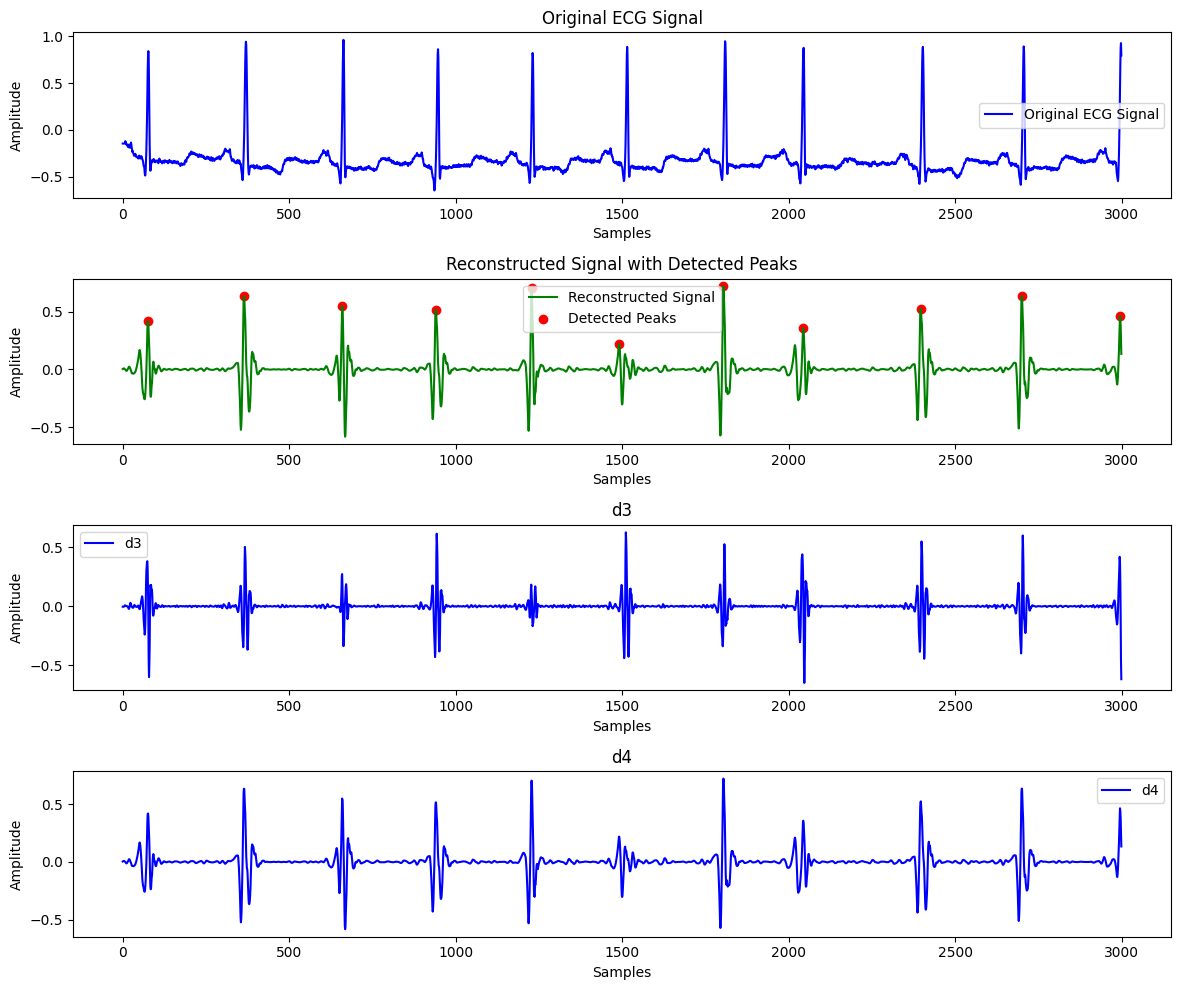

In [120]:
# rpeak test code
coeffs = pywt.wavedec(signals, wavelet='db4', level=4)

d4 = coeffs[1]  # d3 is the third last coefficient
d3 = coeffs[2]  # d4 is the fourth last coefficient


reconst_d3 = pywt.upcoef('d', d3, 'db4', level=3, take=len(signals))
reconst_d4 = pywt.upcoef('d', d4, 'db4', level=4, take=len(signals))

reconst_signal = reconst_d4

distance = int(0.6 * 360)  
peaks, _ = find_peaks(reconst_signal, distance=distance)

zoom_range = (0, 3000)
if zoom_range:
    start, end = zoom_range
    plt_signals = signals[start:end]
    plt_reconst_signal = reconst_signal[start:end]
    plt_peaks = peaks[(peaks >= start) & (peaks < end)] - start
    plt_reconst_d3 = reconst_d3[start:end]
    plt_reconst_d4 = reconst_d4[start:end]

plt.figure(figsize=(12,10))

# Plot original signal
plt.subplot(4, 1, 1)
plt.plot(plt_signals, label="Original ECG Signal", color="blue")
plt.title("Original ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()

# Plot reconstructed signal with detected peaks
plt.subplot(4, 1, 2)
plt.plot(plt_reconst_signal, label="Reconstructed Signal", color="green")
plt.scatter(plt_peaks, plt_reconst_signal[plt_peaks], color="red", label="Detected Peaks")
plt.title("Reconstructed Signal with Detected Peaks")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()

# Plot original signal
plt.subplot(4, 1, 3)
plt.plot(plt_reconst_d3, label="d3", color="blue")
plt.title("d3")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()

# Plot original signal
plt.subplot(4, 1, 4)
plt.plot(plt_reconst_d4, label="d4", color="blue")
plt.title("d4")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
# # 시간 기준 data split
# # 초기화
# train_indices = []
# val_indices = []
# test_indices = []

# # 각 record별로 데이터 분리
# start_idx = 0
# for idx, row in df_records.iterrows():
#     record_name = row['record']
#     num_segments = row['num_segments']
    
#     # 인덱스 범위 계산
#     record_indices = np.arange(start_idx, start_idx + num_segments)
#     start_idx += num_segments
    
#     # 상위 70%, 중간 15%, 하위 15%로 분리
#     num_train = int(num_segments * 0.7)
#     num_val = int(num_segments * 0.15)
#     num_test = num_segments - (num_train + num_val)
    
#     train_indices.extend(record_indices[:num_train])
#     val_indices.extend(record_indices[num_train:num_train + num_val])
#     test_indices.extend(record_indices[num_train + num_val:])

# # 데이터 분리
# x1_train, x1_val, x1_test = x1[train_indices], x1[val_indices], x1[test_indices]
# x2_train, x2_val, x2_test = x2[train_indices], x2[val_indices], x2[test_indices]
# y_train, y_val, y_test = y[train_indices], y[val_indices], y[test_indices]
# records_train, records_val, records_test = records[train_indices], records[val_indices], records[test_indices]

# # 결과 확인
# print("Train Data:")
# print("Segments(x1) Shape:", x1_train.shape)
# print("Extracted Features(x2) Shape:", x2_train.shape)
# print("Labels(y) Shape:", y_train.shape)
# print("Validation Data:")
# print("Segments(x1) Shape:", x1_val.shape)
# print("Extracted Features(x2) Shape:", x2_val.shape)
# print("Labels(y) Shape:", y_val.shape)
# print("Test Data:")
# print("Segments(x1) Shape:", x1_test.shape)
# print("Extracted Features(x2) Shape:", x2_test.shape)
# print("Labels(y) Shape:", y_test.shape)


Train Data:
Segments(x1) Shape: (78767, 300)
Extracted Features(x2) Shape: (78767, 16)
Labels(y) Shape: (78767,)
Validation Data:
Segments(x1) Shape: (16860, 300)
Extracted Features(x2) Shape: (16860, 16)
Labels(y) Shape: (16860,)
Test Data:
Segments(x1) Shape: (16926, 300)
Extracted Features(x2) Shape: (16926, 16)
Labels(y) Shape: (16926,)


In [ ]:
# record 기준 data split
# combine x1, x2 for split
x1x2 = np.hstack((x1, x2))

# data split stratified
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y, groups=records)):
    break    
x1x2_train_val = x1x2[train_val_idx]
y_train_val = y[train_val_idx]
records_train_val = records[train_val_idx]

# Train/Validation 데이터를 다시 StratifiedGroupKFold로 나누기
sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val, groups=records_train_val):
    break  # 첫 번째 split을 사용하여 Train/Validation 분할

x1_train = x1x2_train_val[train_idx][:, :x1.shape[1]]
x2_train = x1x2_train_val[train_idx][:, x1.shape[1]:]
x1_val = x1x2_train_val[val_idx][:, :x1.shape[1]]
x2_val = x1x2_train_val[val_idx][:, x1.shape[1]:]
x1_test = x1x2[test_idx][:, :x1.shape[1]]
x2_test = x1x2[test_idx][:, x1.shape[1]:]

y_train = y_train_val[train_idx]
y_val = y_train_val[val_idx]
y_test = y[test_idx]



In [59]:
# one-hot encoding
y_train_oh, class_names = one_hot_encoder(y_train)
y_val_oh, _ = one_hot_encoder(y_val)
y_test_oh, _ = one_hot_encoder(y_test)

In [60]:
# model initialization
x1_shape = (x1_train.shape[1], 1)
x2_shape = (x2_train.shape[1],)
n_classes = y_train_oh.shape[1]
model = CNNModel(x1_shape, x2_shape, n_classes)   

In [61]:
# model training
model.fit([x1_train, x2_train], y_train_oh, [x1_val, x2_val], y_val_oh, y_train)

Epoch 1/50
2462/2462 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.6930 - loss: 2.4225 - val_accuracy: 0.8555 - val_loss: 0.5380
Epoch 2/50
2462/2462 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.8522 - loss: 0.5671 - val_accuracy: 0.8569 - val_loss: 0.5022
Epoch 3/50
2462/2462 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.8620 - loss: 0.5043 - val_accuracy: 0.8866 - val_loss: 0.4288
Epoch 4/50
 126/2462 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.8776 - loss: 0.4431

KeyboardInterrupt: 

In [13]:
# model evaluation
test_loss, test_accuracy = model.evaluate([x1_test,x2_test], y_test_oh)
print(f"Test accuracy: {test_accuracy:.4f}")

528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8239 - loss: 0.6517
Test accuracy: 0.8233


528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

      Atrial       0.98      0.10      0.18       415
      Normal       0.86      0.91      0.88     11067
       Other       0.89      0.73      0.81      4165
 Ventricular       0.43      0.61      0.50      1236

    accuracy                           0.82     16883
   macro avg       0.79      0.59      0.59     16883
weighted avg       0.84      0.82      0.82     16883

         Class  Precision    Recall  F1-Score  Specificity
0       Atrial   0.976190  0.098795  0.179431     0.999939
1       Normal   0.862356  0.907473  0.884339     0.724381
2        Other   0.890311  0.734694  0.805051     0.970357
3  Ventricular   0.429465  0.610841  0.504342     0.935898


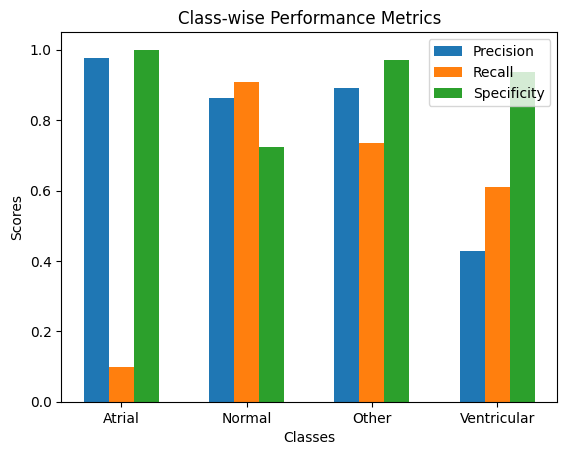

In [14]:
# prediction
y_pred = model.predict([x1_test, x2_test])
y_test = np.argmax(y_test_oh, axis=1)  

# get precision, recall, f1-score, specificity
precision, recall, f1, specificity = calc_metrics(y_test, y_pred, class_names)
global_metrics = calc_global_metrics(y_test, y_pred)

# report
print(classification_report(y_test, y_pred, target_names=class_names))
# get metric df
metric_df = get_metric_df(precision, recall, f1, specificity, class_names)
print(metric_df)


# histogram
plot_metric_hist(precision, recall, specificity, class_names)


In [ ]:
# data export for colab
if colab:
    df_to_csv_colab(metric_df, file_name+'.csv')
    dict_to_json_colab(global_metrics, file_name+'.json')

NameError: name 'file_name' is not defined